In [1]:
# Euskera v1.0

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
cd ..

/Users/armandoroqueestrada/Euskera_data/Euskera_github


Euskera v1.

# Simulation of Solitons without Self-Interaction

In this notebook, we present an illustrative example of the evolution of two solitons: one in the $n = 0$ (stable) state and the other in the $n = 1$ (unstable) state. In this case, there is a scaling freedom:
\begin{align}
t \to \lambda_*^{-1} t, \quad \vec{x}\to \lambda_*^{-1/2} \vec{x},\quad U\to \lambda_x U, \quad \vec\psi \to \lambda_* \vec\psi
\end{align}
As initial profiles, we use the linear constant polarization profiles (see the notebook example_making_initial_profile). For more details, see the documentation.


In [4]:
import multiprocessing
import euskera as eu

import numpy as np
import matplotlib.pyplot as plt 

from scipy import interpolate

At this point, we have the initial profile used to create our initial configuration, but first, we need to transform it into Euskera units.

Relations

$$
t_{paper} = t_{euskera}, \quad x_{paper} = \sqrt{2} x_{euskera}, \quad \psi_{paper} = \sqrt{2\pi}\psi_{euskera}, \quad U_{paper} = U_{euskera}, \quad \lambda_{paper} = \frac{\lambda_{euskera}}{4\pi}
$$

In [5]:
# loading the profiles
dataEx = np.load("profiles/profiles_const_lam_0_n_0_1.npz", allow_pickle=True)['arr_0']

In [6]:
### Generating the profiles data with an iteration dx
dx = 0.00001

parameters = ['profiles', 'potential_profiles', 'E_data', 'M_data', 'lambda']
data_Proca = {key: [] for key in parameters} # to save the mass for each profile
##################################################################
for s0 in dataEx:
    Ei, Mass, rDnew, sDnew, dsDnew, uDnew, duDnew, LamV = s0
    
    ### scaling to Euskera variables
    rE = rDnew/np.sqrt(2)
    sd = sDnew/np.sqrt(2*np.pi)
    LambdaV = 4 * np.pi * LamV
        
    rad2 = np.arange(rE[0], rE[-1], dx)
    ftemp = interpolate.interp1d(rE, sd)  # interpolating
    sdE2x = ftemp(rad2)

    ftemp = interpolate.interp1d(rE, Ei - uDnew)
    uDnewE2x = ftemp(rad2)

    # computing the mass
    Mas = eu.massVal(rE, sd, gamma=0, fac=4*np.pi, kind='quadratic', fill_value="extrapolate")    
    
    data_Proca['profiles'].append(sdE2x)
    data_Proca['potential_profiles'].append(uDnewE2x)
    data_Proca['E_data'].append(Ei)
    data_Proca['M_data'].append(Mas)
    data_Proca['lambda'].append(LambdaV)

    print("Energy -> ", Ei)    
    print("Mass using Euskera -> ", Mas, "Mass using convertion -> ", Mass/(np.sqrt(2*np.pi)**2*np.sqrt(2)**3)) # check

Energy ->  -0.9789591957601331
Mass using Euskera ->  2.4524274612065935 Mass using convertion ->  2.452427458457671
Energy ->  -0.9162746282239667
Mass using Euskera ->  5.454587177838958 Mass using convertion ->  5.454587152796816


### $n = 0$ Simulation

In [8]:
dx = 0.00001
index = 0

(0.0, 83.97569)

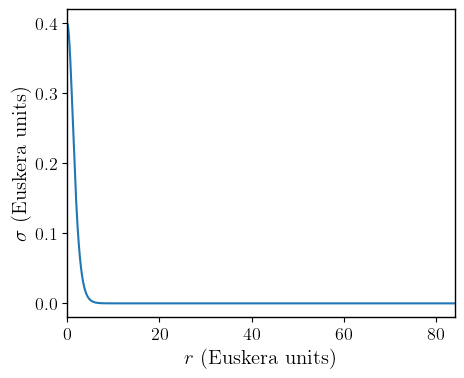

In [9]:
# Uncomment if you want to plot the used profiles.
fProca = data_Proca['profiles'][index]
rn = np.arange(len(fProca)) * dx

plt.figure(figsize=(5, 4))

componets = ['x', 'y', 'z']
color = ['k', 'b', 'r']
plt.plot(rn, fProca)

plt.xlabel(r"$r$ (Euskera units)")
plt.ylabel(r"$\sigma$ (Euskera units)")
plt.xlim(0, rn[-1])
#plt.yscale('log')

In [10]:
fProca = data_Proca['profiles'][index]
EProc = data_Proca['E_data'][index]
Mn0 = data_Proca['M_data'][index]
lambda_value = data_Proca['lambda'][index]

dx = 0.00001
# rn = np.arange(len(fProca)) * dx
rlim = 20 # rn[-1]  # limit of r take to used on the simulation

tmax = 200  # limit of time take to used on the simulation
save_number = 2 * int(tmax)  # number of the save
resol = 160


name_save = "simulation_data/profile_soliton_n_%d"%index  # save-name 

print('#'*3, ' Data Simulation')
print("Energy: ", EProc)
print("Lambda value: ", lambda_value)
print("Saving the profile in: ", name_save)
print("Resolution: ", resol)
print("Number of frame saved: ", save_number)
print("Simulation time: ", tmax)

###  Data Simulation
Energy:  -0.9789591957601331
Lambda value:  0.0
Saving the profile in:  simulation_data/profile_soliton_n_0
Resolution:  160
Number of frame saved:  400
Simulation time:  200


In [11]:
#### identifying the cpu_processing number
num_threads = multiprocessing.cpu_count()  

#### Symulation Parameters
simulation_parameters = {
"lambda_value": lambda_value,  # Self-interaction coupling constant.
"num_threads": num_threads,  # Set the number of threads to use.
"gridlength": 4*rlim,  # Length of the grid in codec units.
"resol": resol, # Grid resolution. The grid is computed using:
              # linspace(-gridlength/2.0 + gridlength/(2.0*resol), 
              #           gridlength/2.0 - gridlength/(2.0*resol), resol).
"step_factor": 1.,  # Increase this if velocities are low enough that the timestep constraint can be relaxed.
"t0": 0,  # Initial time.
"tmax": tmax,  # Total simulation time.
"Plim": rlim,  # Boundary radius of the soliton.
"rmax": 2*rlim,  # Two rmax define the minimum separation between solitons 
                 # to ensure they are not overlapping.
"cmass": 0,  # Central mass, given in the same units as the soliton mass.
"plott0": False,  # Show the initial profile if True.
"Boverlap": False,  # Check for possible overlap if True.
"methodEnerg": 1,  # methodology used to computed the kinetic contribution
"info": False  # Print extra information if True.
}

#### Save data information/parameters
salva_data = {
  "format": "npz",  # Format used to save data. Supported formats: "npz" and "hdf5".
  "address": name_save,  # Directory where the data will be saved.
  "save_number": save_number,  # Number of frames to save within the time interval [t0, tmax].
  "data_save" : {"grid": True,  # Save grid data.
                 "save_rho": False,   # Save density field (ρ) if True.
                 "save_psi": False,  # Save wavefunction (ψ) if True.
                 "save_phi": False,  # Save potential (φ) if True.
                 "save_plane_rho": True,  # Save plane projections  [:, :, resol/2,]] if True.
                 "save_plane_psi": False,
                 "save_plane_phi": False,
                 "save_line_rho": True, # Save 1D profile along a specific line [:, resol/2,, resol/2,]]  if True.
                 "save_line_psi": True,
                 "save_line_phi": True,
                 "save_energies": True # Save energy values if specified.
                 }
}

comp_conserv = {
        "Numb_Part": True,
        "Energ": True,
        "Pi": False,
        "Ji": False,
        "Frequency": True
}

# Estimating the time step
ht, its_per_save, num_steps = eu.dtime(tmax, simulation_parameters['gridlength'],
                                       resol, simulation_parameters['step_factor'], save_number)

dt = its_per_save * ht
print("Time between saved iteration (n -> %d) "%its_per_save, dt)
print("Total time -> ", dt * save_number, " (equivalent to tmax) ", tmax)

Time between saved iteration (n -> 7)  0.5
Total time ->  200.0  (equivalent to tmax)  200


In [12]:
###### Used Model
modelS = "soliton"
nume_soliton = 1 # Number of solitons to be used in the simulation.

###### Parameters for Components
compfield = 1  # Number of soliton components (for a scalar field: 1, for a vector field: 2, e.g., Ψ = [ψ_x, ψ_y], etc.)

# Component Profiles
sol1 = [fProca]  # If Ψ is a vector (e.g., Ψ = [ψ_x, ψ_y, ψ_z]), specify [fx, fy, fz].
solT = [sol1]

# Energy Eigenvalues for Each Component
beta1 = [EProc]  # If Ψ is a vector, specify [En0, En0].
betaT = [beta1]

###### Configuration Parameters
# Central Positions (x0, y0, z0)
csol1 = [0., 0., 0.]
csolT = [csol1]

# Velocities
vsol1 = [0., 0., 0.]
vsolT = [vsol1]*nume_soliton

# Phases
phase1 = [0.]
phaseT = [phase1]*nume_soliton

# Alpha values (only for the non-self-interacting case; otherwise, set to 1)
alpha = lambda massC, mass: (massC / mass) ** 2  # Conversion factor
alpha1 = [alpha(Mn0, Mn0)]
alphaT = [alpha1] * nume_soliton

# Step size (dr) used to computed the radial profiles previusly
delta_r = dx
dr1 = [delta_r]
drT = [dr1] * nume_soliton

In [13]:
parameters_sol = {
  modelS: [{"profiles": solT[i], "positions": csolT[i], "velocities": vsolT[i], "betas": betaT[i],
            "phases": phaseT[i], "alphas": alphaT[i], "dr": drT[i]} for i in range(0, nume_soliton)]
}

In [14]:
# Beginning the simulation
eu.evolve(model_parameters=parameters_sol,
           field_components=compfield,
           salva_data_update=salva_data,
           simulation_parameters_update=simulation_parameters,
           comp_conserv_update=comp_conserv,
           info=False)

########## Parameters saved ##########
File saved at: /Users/armandoroqueestrada/Euskera_data/Euskera_github/simulation_data/profile_soliton_n_0/parameters.txt
Progress: [####################] 100%
 All data was save


Complete. Total time ->  239.66802549362183
save_frames 401 



### $n = 1$ Simulation

In [15]:
dx = 0.00001
index = 1

(0.0, 88.69834)

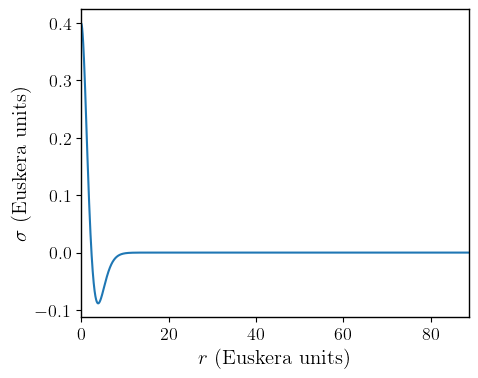

In [16]:
# Uncomment if you want to plot the used profiles.
fProca = data_Proca['profiles'][index]
rn = np.arange(len(fProca)) * dx

plt.figure(figsize=(5, 4))

componets = ['x', 'y', 'z']
color = ['k', 'b', 'r']
plt.plot(rn, fProca)

plt.xlabel(r"$r$ (Euskera units)")
plt.ylabel(r"$\sigma$ (Euskera units)")
plt.xlim(0, rn[-1])
#plt.yscale('log')

In [20]:
fProca = data_Proca['profiles'][index]
EProc = data_Proca['E_data'][index]
Mn0 = data_Proca['M_data'][index]
lambda_value = data_Proca['lambda'][index]

dx = 0.00001
# rn = np.arange(len(fProca)) * dx
rlim = 20 # rn[-1]  # limit of r take to used on the simulation

tmax = 200  # limit of time take to used on the simulation
save_number = 2 * int(tmax)  # number of the save
resol = 160


name_save = "simulation_data/profile_soliton_n_%d"%index  # save-name 

print('#'*3, ' Data Simulation')
print("Energy: ", EProc)
print("Lambda value: ", lambda_value)
print("Saving the profile in: ", name_save)
print("Resolution: ", resol)
print("Number of frame saved: ", save_number)
print("Simulation time: ", tmax)


#### identifying the cpu_processing number
num_threads = multiprocessing.cpu_count()  

#### Symulation Parameters
simulation_parameters = {
"lambda_value": lambda_value,  # Self-interaction coupling constant.
"num_threads": num_threads,  # Set the number of threads to use.
"gridlength": 4*rlim,  # Length of the grid in codec units.
"resol": resol, # Grid resolution. The grid is computed using:
              # linspace(-gridlength/2.0 + gridlength/(2.0*resol), 
              #           gridlength/2.0 - gridlength/(2.0*resol), resol).
"step_factor": 1.,  # Increase this if velocities are low enough that the timestep constraint can be relaxed.
"t0": 0,  # Initial time.
"tmax": tmax,  # Total simulation time.
"Plim": rlim,  # Boundary radius of the soliton.
"rmax": 2*rlim,  # Two rmax define the minimum separation between solitons 
                 # to ensure they are not overlapping.
"cmass": 0,  # Central mass, given in the same units as the soliton mass.
"plott0": True,  # Show the initial profile if True.
"Boverlap": False,  # Check for possible overlap if True.
"methodEnerg": 1,  # methodology used to computed the kinetic contribution
"info": False  # Print extra information if True.
}

#### Save data information/parameters
salva_data = {
  "format": "npz",  # Format used to save data. Supported formats: "npz" and "hdf5".
  "address": name_save,  # Directory where the data will be saved.
  "save_number": save_number,  # Number of frames to save within the time interval [t0, tmax].
  "data_save" : {"grid": True,  # Save grid data.
                 "save_rho": False,   # Save density field (ρ) if True.
                 "save_psi": False,  # Save wavefunction (ψ) if True.
                 "save_phi": False,  # Save potential (φ) if True.
                 "save_plane_rho": True,  # Save plane projections  [:, :, resol/2,]] if True.
                 "save_plane_psi": False,
                 "save_plane_phi": False,
                 "save_line_rho": True, # Save 1D profile along a specific line [:, resol/2,, resol/2,]]  if True.
                 "save_line_psi": True,
                 "save_line_phi": True,
                 "save_energies": True # Save energy values if specified.
                 }
}

comp_conserv = {
        "Numb_Part": True,
        "Energ": True,
        "Pi": False,
        "Ji": False,
        "Frequency": True
}

# Estimating the time step
ht, its_per_save, num_steps = eu.dtime(tmax, simulation_parameters['gridlength'],
                                       resol, simulation_parameters['step_factor'], save_number)

dt = its_per_save * ht
print("Time between saved iteration (n -> %d) "%its_per_save, dt)
print("Total time -> ", dt * save_number, " (equivalent to tmax) ", tmax)

###  Data Simulation
Energy:  -0.9162746282239667
Lambda value:  0.0
Saving the profile in:  simulation_data/profile_soliton_n_1
Resolution:  160
Number of frame saved:  400
Simulation time:  200
Time between saved iteration (n -> 7)  0.5
Total time ->  200.0  (equivalent to tmax)  200


In [21]:
###### Used Model
modelS = "soliton"
nume_soliton = 1 # Number of solitons to be used in the simulation.

###### Parameters for Components
compfield = 1  # Number of soliton components (for a scalar field: 1, for a vector field: 2, e.g., Ψ = [ψ_x, ψ_y], etc.)

# Component Profiles
sol1 = [fProca]  # If Ψ is a vector (e.g., Ψ = [ψ_x, ψ_y, ψ_z]), specify [fx, fy, fz].
solT = [sol1]

# Energy Eigenvalues for Each Component
beta1 = [EProc]  # If Ψ is a vector, specify [En0, En0].
betaT = [beta1]

###### Configuration Parameters
# Central Positions (x0, y0, z0)
csol1 = [0., 0., 0.]
csolT = [csol1]

# Velocities
vsol1 = [0., 0., 0.]
vsolT = [vsol1]*nume_soliton

# Phases
phase1 = [0.]
phaseT = [phase1]*nume_soliton

# Alpha values (only for the non-self-interacting case; otherwise, set to 1)
alpha = lambda massC, mass: (massC / mass) ** 2  # Conversion factor
alpha1 = [alpha(Mn0, Mn0)]
alphaT = [alpha1] * nume_soliton

# Step size (dr) used to computed the radial profiles previusly
delta_r = dx
dr1 = [delta_r]
drT = [dr1] * nume_soliton

parameters_sol = {
  modelS: [{"profiles": solT[i], "positions": csolT[i], "velocities": vsolT[i], "betas": betaT[i],
            "phases": phaseT[i], "alphas": alphaT[i], "dr": drT[i]} for i in range(0, nume_soliton)]
}

########## Parameters saved ##########
File saved at: /Users/armandoroqueestrada/Euskera_data/Euskera_github/simulation_data/profile_soliton_n_1/parameters.txt
Showing the Z=0, X-Y plane


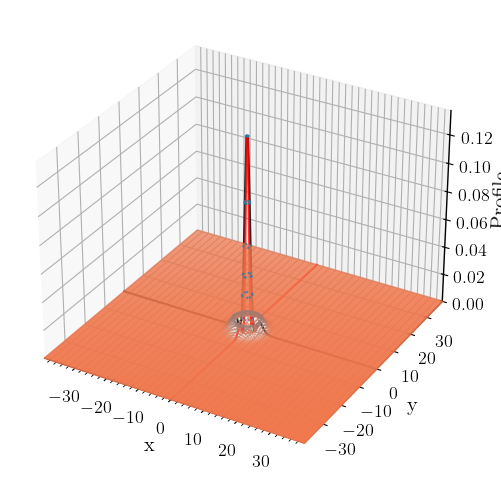

Showing the Z=0, X-Y plane


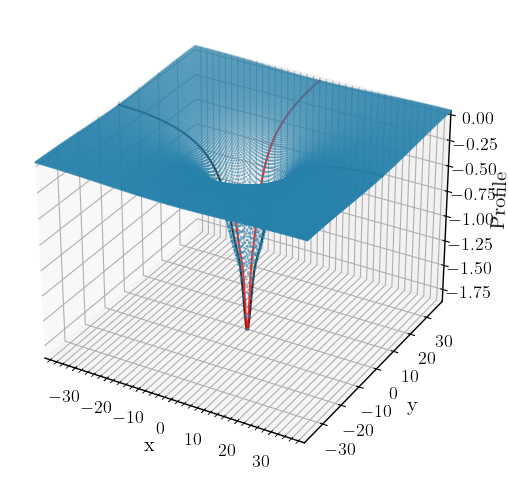

Progress: [####################] 100%
 All data was save


Complete. Total time ->  231.6787567138672
save_frames 401 



In [22]:
# Beginning the simulation
eu.evolve(model_parameters=parameters_sol,
           field_components=compfield,
           salva_data_update=salva_data,
           simulation_parameters_update=simulation_parameters,
           comp_conserv_update=comp_conserv,
           info=False)